In [1]:
# --- SETUP: IMPORTS AND CONFIGURATION ---

import re
import subprocess
from pathlib import Path
from typing import Optional, Union, Callable

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt


pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
# --- Helper: parse the Tcl variant registry / clock campaigns, so this ---
# --- notebook never drifts out of sync with scripts/project-03/*.tcl   ---
def _parse_tcl_variants(tcl_path: Path) -> dict:
    '''Parses the `array set ::VARIANTS {...}` block in variants.tcl.'''
    text = tcl_path.read_text()
    match = re.search(r"array set ::VARIANTS \{(.*?)\n\}", text, re.DOTALL)
    if not match:
        raise ValueError(f"Could not find ::VARIANTS array in {tcl_path}")

    variants = {}
    for line in match.group(1).strip().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        entry_match = re.match(r"(\S+)\s+\{(.+)\}", line)
        if not entry_match:
            continue
        name, fields_str = entry_match.groups()
        fields = fields_str.split()
        if len(fields) != 5:
            continue
        top_entity, vhd_file, report_subfolder, sim_configuration, pipeline_latency = fields
        variants[name] = {
            "top_entity": top_entity,
            "vhd_file": vhd_file,
            "report_subfolder": report_subfolder,
            "sim_configuration": sim_configuration,
            "pipeline_latency": int(pipeline_latency),
        }
    return variants

In [3]:
# --- CONSTANTS: PATHS, SIMULATION CONFIGURATIONS, CLOCK CAMPAIGNS ---

# --- Paths ---
REPO_ROOT          = Path("..").resolve()
SCRIPTS_DIR        = REPO_ROOT / "scripts" / "project-03"
RES_SRC_DIR         = REPO_ROOT / "res" / "srcs" / "project-03"
OUTPUT_FIG_FOLDER  = REPO_ROOT / "notebooks" / "output" / "project-03" / "figs"
OUTPUT_SIM_FOLDER  = REPO_ROOT / "notebooks" / "output" / "project-03" / "sims"
LOGS_FOLDER        = OUTPUT_SIM_FOLDER / "logs"
REPORTS_ROOT       = OUTPUT_SIM_FOLDER / "reports"
OUTPUT_FIG_FOLDER.mkdir(parents=True, exist_ok=True)
REPORTS_ROOT.mkdir(parents=True, exist_ok=True)

# --- Vivado executable (update to the full path if not on PATH) ---
VIVADO_EXE = "vivado"

# --- Fallback registry, used only if the Tcl files cannot be parsed ---
# --- (e.g. this notebook run standalone without the scripts/ folder) ---
_FALLBACK_VARIANTS = {
    "baseline":               {"top_entity": "top_baseline",               "vhd_file": "top_baseline.vhd",               "report_subfolder": "baseline",               "sim_configuration": "cfg_baseline",               "pipeline_latency": 2},
    "registering":            {"top_entity": "top_registering",            "vhd_file": "top_registering.vhd",            "report_subfolder": "registering",            "sim_configuration": "cfg_registering",            "pipeline_latency": 4},
    "reordering":             {"top_entity": "top_reordering",             "vhd_file": "top_reordering.vhd",             "report_subfolder": "reordering",             "sim_configuration": "cfg_reordering",             "pipeline_latency": 2},
    "reordering_registering": {"top_entity": "top_reordering_registering", "vhd_file": "top_reordering_registering.vhd", "report_subfolder": "reordering_registering", "sim_configuration": "cfg_reordering_registering", "pipeline_latency": 4},
    "isolated_reordering":    {"top_entity": "top_isolated_reordering",    "vhd_file": "top_isolated_reordering.vhd",    "report_subfolder": "isolated_reordering",    "sim_configuration": "cfg_isolated_reordering",    "pipeline_latency": 4},
}
CLOCK_CAMPAIGNS = [10.0, 9.0, 8.0, 7.0, 6.0]

RENAME_DICT = {
        "variant":              "Variant",
        "clk_period_ns":        "Clock Period [ns]",
        "lut":                  "LUTs [1]",
        "ff":                   "FFs [1]",
        "wns_ns":               "WNS [ns]",
        "fmax_mhz":             "fmax [MHz]",
        "logic_power_mw":       "Power (Logic) [mW]",
        "signals_power_mw":     "Power (Signals) [mW]",
        "clock_power_mw":       "Power (Clock) [mW]",
        "io_power_mw":          "Power (I/0) [mW]",
        "dynamic_power_mw":     "Power (Dynamic) [mW]",
        "static_power_mw":      "Power (Static) [mW]",
        "total_power_mw":       "Power (Total) [mW]",
    }

RENAME_VARIANTS = {
    "baseline":               "Baseline",
    "registering":            "Pipeline Registering",
    "reordering":             "Pre-Computing Reordering",
    "reordering_registering": "Pre-Computing Pipeline",
    "isolated_reordering":    "Gated Pre-Computing",
}

try:
    VARIANTS = _parse_tcl_variants(SCRIPTS_DIR / "variants.tcl")
except (FileNotFoundError, ValueError) as exc:
    print(f"WARNING: could not parse variants.tcl ({exc}); using the fallback registry.")
    VARIANTS = _FALLBACK_VARIANTS

print(f"Registered variants: {list(VARIANTS.keys())}")
print(f"Clock campaigns (ns): {CLOCK_CAMPAIGNS}")

Registered variants: ['baseline', 'registering', 'reordering', 'reordering_registering', 'isolated_reordering']
Clock campaigns (ns): [10.0, 9.0, 8.0, 7.0, 6.0]


In [4]:
# --- Helper: Vivado report parsers ---
# NOTE: these regexes match the standard Vivado report_utilization /
# report_timing_summary / report_power text layout, but have not been
# validated against a real, generated report (no Vivado install available
# in this environment). Verify against the first real report and adjust
# if this Vivado version's exact formatting differs.

def _parse_utilization_report(path: Path) -> dict:
    text = path.read_text()
    lut_match = re.search(r"\|\s*Slice LUTs\s*\|\s*(\d+)", text)
    ff_match = re.search(r"\|\s*Slice Registers\s*\|\s*(\d+)", text)
    if ff_match is None:
        ff_match = re.search(r"\|\s*Register as Flip Flop\s*\|\s*(\d+)", text)
    return {
        "lut": int(lut_match.group(1)) if lut_match else None,
        "ff": int(ff_match.group(1)) if ff_match else None,
    }


def _parse_timing_summary_report(path: Path) -> dict:
    lines_ = path.read_text().splitlines()
    wns_ns = None
    for i, line in enumerate(lines_):
        if "WNS(ns)" in line:
            for candidate in lines_[i + 1: i + 4]:
                candidate = candidate.strip()
                if candidate and not set(candidate) <= {"-", " "}:
                    tokens = candidate.split()
                    try:
                        wns_ns = float(tokens[0])
                    except (ValueError, IndexError):
                        continue
                    break
            break
    return {"wns_ns": wns_ns}


def _extract_signals_power(report_text: str) -> float | None:
    """
    Parses a Vivado plain text power report to extract the Signals power in Watts.
    Returns the power as a float, or None if not found.
    """
    # Look for the row containing "Signals", ignoring exact whitespace amounts,
    # and capture the numeric value in the next column.
    match = re.search(r"\|\s*Signals\s*\|\s*([\d.]+)", report_text)

    if match:
        return float(match.group(1))

    return None

def _parse_power_report(path: Path) -> dict[str, Optional[float]]:
    """
    Parses a Vivado Power Analysis (.xpe) XML file to extract power metrics
    with updated output categories.
    """
    tree = ET.parse(path)
    root = tree.getroot()

    def _sum_attributes(xpath: str, attribute: str) -> Optional[float]:
        """
        Extracts and sums a specific attribute from all elements matching the XPath.
        Returns None if no matching elements are found.
        """
        elements = root.findall(xpath)
        if not elements:
            return None

        total = 0.0
        for elem in elements:
            val = elem.attrib.get(attribute)
            if val is not None:
                try:
                    total += float(val)
                except ValueError:
                    continue
        return total

    # Parse standard functional blocks
    clocks_w = _sum_attributes(".//BLOCKTYPE[@name='Clocks']/CLOCK", "power")
    logic_w = _sum_attributes(".//BLOCKTYPE[@name='LOGIC']/LOGIC", "power")

    # Calculate I/O power by summing distinct voltage contributions for each IO group
    io_elements = root.findall(".//BLOCKTYPE[@name='IO']/MODULE/GROUPSUMMARY/IO")
    io_w = None
    if io_elements:
        io_w = 0.0
        for io_elem in io_elements:
            for attr in ['vccInt', 'vccAux', 'vcco']:
                val = io_elem.attrib.get(attr)
                if val is not None:
                    io_w += float(val)

    # Calculate static and total power from voltage sources
    device_static_w = 0.0
    total_on_chip_w = 0.0
    sources = root.findall(".//VOLTAGESOURCES/SOURCE")

    if sources:
        for source in sources:
            voltage = float(source.attrib.get('voltage', '0.0'))
            iccq = float(source.attrib.get('iccq', '0.0'))
            power = float(source.attrib.get('power', '0.0'))

            # Static power per rail = Voltage * Quiescent Current (iccq)
            device_static_w += (voltage * iccq)
            total_on_chip_w += power
    else:
        device_static_w = None
        total_on_chip_w = None

    def _round_opt(val: Optional[float]) -> Optional[float]:
        return round(val, 6) if val is not None else None

    return {
        "Clocks": _round_opt(clocks_w),
        "Slice Logic": _round_opt(logic_w),
        "I/O": _round_opt(io_w),
        "Static Power": _round_opt(device_static_w),
        "Total": _round_opt(total_on_chip_w),
    }


def _parse_simulation_log(path: Path) -> dict:
    if not path.exists():
        return {"checks": None, "errors": None, "passed": None}

    text = path.read_text(errors="ignore")

    # Aggiornato per cercare esattamente il nuovo formato "[TB] X checks, Y errors"
    checks_match = re.search(r"\[TB\]\s*(\d+)\s*checks,\s*(\d+)\s*errors", text)

    # Valuta la presenza dei nuovi flag
    passed_flag = "[TB] PASS" in text
    failed_flag = "[TB] FAIL" in text

    return {
        "checks": int(checks_match.group(1)) if checks_match else 0,
        "errors": int(checks_match.group(2)) if checks_match else 0,
        "passed": (passed_flag if (passed_flag or failed_flag) else False),
    }



def _collect_variant_metrics(variant_name: str, clk_period_ns: float) -> Optional[dict[str, any]]: # pyright: ignore[reportGeneralTypeIssues]
    """
    Parses every report for (variant_name, clk_period_ns) into a single
    flat dict, or returns None if the reports have not been generated yet.
    """
    report_subfolder = f"{variant_name}_{clk_period_ns:.1f}"
    reports_dir = REPORTS_ROOT / report_subfolder

    util_path   = reports_dir / "utilization.rpt"
    timing_path = reports_dir / "timing_summary.rpt"
    power_path  = reports_dir / "power.xpe"
    txt_power_path = reports_dir / "power.rpt"

    if not (util_path.exists() and timing_path.exists() and power_path.exists()):
        return None

    util   = _parse_utilization_report(util_path)
    timing = _parse_timing_summary_report(timing_path)
    power  = _parse_power_report(power_path)

    wns_ns = timing.get("wns_ns")
    fmax_mhz = None
    if wns_ns is not None and (clk_period_ns - wns_ns) > 0:
        fmax_mhz = 1e3 / (clk_period_ns - wns_ns)

    # Updated keys to match the newly defined categories in _parse_power_report
    logic_mw   = (power.get("Slice Logic") or 0.0) * 1e3
    signals_mw = (_extract_signals_power(txt_power_path.read_text()) or 0.0) * 1e3
    clock_mw   = (power.get("Clocks") or 0.0) * 1e3
    io_mw      = (power.get("I/O") or 0.0) * 1e3
    dynamic_mw = (logic_mw + signals_mw + clock_mw)
    static_mw  = (power.get("Static Power") or 0.0) * 1e3
    total_mw   = (power.get("Total") or 0.0) * 1e3

    return {
        "variant":           variant_name,
        "clk_period_ns":     clk_period_ns,
        "lut":               util.get("lut"),
        "ff":                util.get("ff"),
        "wns_ns":            wns_ns,
        "fmax_mhz":          fmax_mhz,
        "logic_power_mw":    logic_mw,
        "signals_power_mw":  signals_mw,
        "clock_power_mw":    clock_mw,
        "io_power_mw":       io_mw,
        "dynamic_power_mw":  dynamic_mw,
        "static_power_mw":   static_mw,
        "total_power_mw":    total_mw,
    }


def _run_variant_via_vivado(variant_name: str, clk_period_ns: float, dut_instance_path: str = None): # pyright: ignore[reportArgumentType]
    '''Invokes scripts/project-03/run_variant.tcl via subprocess for a
    single (variant, clk_period_ns) combination. Requires Vivado installed
    and PART_NAME set in create_project.tcl.'''
    report_subfolder = VARIANTS[variant_name]["report_subfolder"]
    reports_dir = REPORTS_ROOT / report_subfolder
    reports_dir.mkdir(parents=True, exist_ok=True)
    log_path = reports_dir / f"vivado_console_{clk_period_ns}ns.log"

    args = [
        VIVADO_EXE, "-mode", "batch", "-log", str(log_path),
        "-source", str(SCRIPTS_DIR / "run_variant.tcl"),
        "-tclargs", variant_name, str(clk_period_ns),
    ]
    if dut_instance_path:
        args.append(dut_instance_path)

    print(f"Running: {' '.join(args)}")
    result = subprocess.run(args, cwd=REPO_ROOT, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout[-3000:])
        print(result.stderr[-3000:])
        raise RuntimeError(
            f"run_variant.tcl failed for {variant_name} @ {clk_period_ns}ns "
            f"(exit {result.returncode}); see {log_path}"
        )
    print(f"Done: {variant_name} @ {clk_period_ns}ns -> {reports_dir}")

In [5]:
# --- Helpers: visualization ---

def _transform_dataframe(
    df: pd.DataFrame,
    rename_dict: dict[str, str] = None, # pyright: ignore[reportArgumentType]
    scale_dict: dict[str, Union[str, Callable[[pd.Series], pd.Series]]] = None # pyright: ignore[reportArgumentType]
) -> pd.DataFrame:
    """Transforms a DataFrame by applying scaling strategies and renaming columns.

    Args:
        df (pd.DataFrame): The input DataFrame to transform.
        rename_dict (dict[str, str], optional): Mapping of original column names to new names. Defaults to None.
        scale_dict (dict[str, Union[str, Callable]], optional): Mapping of original column names to scaling configurations.
            Supported string strategies are 'minmax' and 'standard'. Custom callables mapping a Series to a Series are also supported. Defaults to None.

    Returns:
        pd.DataFrame: A new DataFrame instance with applied transformations.

    Raises:
        ValueError: If an unsupported string scaling strategy is provided.
    """
    # Create a copy to prevent mutating the original reference
    processed_df = df.copy()

    # Apply scaling transformations using the original column names
    if scale_dict:
        for col, method in scale_dict.items():
            if col not in processed_df.columns:
                continue

            series = processed_df[col]

            if callable(method):
                processed_df[col] = method(series)
            elif isinstance(method, str):
                method_lower = method.lower()

                if method_lower == 'minmax':
                    col_min = series.min()
                    col_max = series.max()
                    if col_max != col_min:
                        processed_df[col] = (series - col_min) / (col_max - col_min)
                    else:
                        processed_df[col] = 0.0

                elif method_lower == 'standard':
                    col_mean = series.mean()
                    col_std = series.std()
                    if col_std != 0:
                        processed_df[col] = (series - col_mean) / col_std
                    else:
                        processed_df[col] = 0.0
                else:
                    raise ValueError(f"Unsupported scaling strategy: '{method}'. Use 'minmax', 'standard', or a custom callable.")

    # Apply header renaming after scaling operations
    if rename_dict:
        processed_df = processed_df.rename(columns=rename_dict)

    return processed_df

def _format_cell(val, decimals: int = 5) -> str:
    """Formats a DataFrame cell to prevent raw object representation and strip floating-point artifacts.

    Args:
        val (Any): The cell value to format.
        decimals (int, optional): Number of decimal places to round floats. Defaults to 5.

    Returns:
        str: The formatted string representation of the cell.
    """
    if pd.isna(val):
        return "NaN"

    if isinstance(val, (float, np.floating)):
        # Round the value to eliminate artifacts from operations like * 1e15
        rounded_val = round(float(val), decimals)

        # Cast to integer string if the rounded value has no fractional part
        if rounded_val.is_integer():
            return str(int(rounded_val))

        return str(rounded_val)

    return str(val)

def _summary_display(df: pd.DataFrame, n_head: int = 5, n_tail: int = 0) -> pd.DataFrame:
    """Generates a string-formatted summary DataFrame with a central ellipsis row for UI rendering.

    Args:
        df (pd.DataFrame): The target DataFrame.
        n_head (int, optional): Number of top rows to display. Defaults to 5.
        n_tail (int, optional): Number of bottom rows to display. Set to >0 to append the tail. Set to -1 to omit the tail. Defaults to 0.

    Returns:
        pd.DataFrame: A string-cast DataFrame containing the sliced data and the ellipsis separator.
    """
    # Format and isolate the head components
    df_head = df.head(n_head).apply(lambda col: col.map(_format_cell))

    # Generate the single ellipsis row container
    if n_tail != -1:
        dummy_row = pd.DataFrame(
            [['...'] * len(df.columns)],
            columns=df.columns,
            index=['...']
        )

        chunks = [df_head, dummy_row]
    else:
        chunks = [df_head]

    # Trigger Behavior 2 if n_tail is explicitly requested
    if n_tail > 0:
        df_tail = df.tail(n_tail).apply(lambda col: col.map(_format_cell))
        chunks.append(df_tail)

    return pd.concat(chunks)

In [6]:
def _run_step(solution: str) -> pd.DataFrame:
    metrics_result = []
    for clk in CLOCK_CAMPAIGNS:
        log_path = LOGS_FOLDER / f"{solution}_{clk:.1f}ns.log"

        # Check if the log has been generated
        if not log_path.exists():
            print(f"Log not found: {log_path}")
            print("Run the TCL flow first (see markdown description), then re-run this cell.")
            raise RuntimeError(f"Log not found: {log_path}")

        # Print the run results
        sim_result = _parse_simulation_log(log_path)
        print(f"{solution} @ {clk:.1f}ns functional check:")
        print(f"  Passed_checks: {sim_result['checks']-sim_result['errors']}/{sim_result['checks']}")
        print(f"  Result:        {"PASSED" if sim_result['passed'] else "FAILED"}")

        metrics = _collect_variant_metrics(solution, clk)

        if metrics is None:
            print(f"Reports not found for '{solution}' @ {clk:.1f}ns.")
            print("Ivalid solution or clock rate.")

            metrics = {
                "variant":              solution,
                "clk_period_ns":        clk,
                "lut":                  np.nan,
                "ff":                   np.nan,
                "wns_ns":               np.nan,
                "fmax_mhz":             np.nan,
                "logic_power_mw":       np.nan,
                "signals_power_mw":     np.nan,
                "clock_power_mw":       np.nan,
                "io_power_mw":          np.nan,
                "dynamic_power_mw":     np.nan,
                "static_power_mw":      np.nan,
                "total_power_mw":       np.nan,
            }

        metrics_result.append(metrics)

    return pd.DataFrame(metrics_result)

## STEP 01 – Baseline RTL Implementation and Functional Verification

The Baseline RTL (`top_baseline.vhd`) and the shared, latency-agnostic
testbench (`tb_top.vhd`) are implemented directly in VHDL under
`res/src/project-03/` (see `docs/projects.md`, STEP 1), not orchestrated
from Python.

Functional correctness is verified by `tb_top`'s self-checking reference
pipelin and runned synthesis, implementation, and the post-implementation SAIF-based power
report are produced externally by `scripts/project-03/run_variant.tcl`
(see `docs/projects.md`, STEP 2). This step parses the exported
`utilization.rpt`, `timing_summary.rpt`, and `power.rpt` for the Baseline
variant at the standard clock constraint, establishing the reference
metrics used as the comparison anchor in `STEP 06`.

In [7]:
# --- STEP 01: COLLECT BASELINE METRICS ---

baseline_metrics = _run_step("baseline")

_summary_display(
    _transform_dataframe(
        baseline_metrics,
        rename_dict=RENAME_DICT
    ),
    n_head=len(baseline_metrics),
    n_tail=-1
)

baseline @ 10.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
baseline @ 9.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
baseline @ 8.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
baseline @ 7.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
baseline @ 6.0ns functional check:
  Passed_checks: 0/0
  Result:        FAILED
Reports not found for 'baseline' @ 6.0ns.
Ivalid solution or clock rate.


,Variant,Clock Period [ns],LUTs [1],FFs [1],WNS [ns],fmax [MHz],Power (Logic) [mW],Power (Signals) [mW],Power (Clock) [mW],Power (I/0) [mW],Power (Dynamic) [mW],Power (Static) [mW],Power (Total) [mW]
0,baseline,10,126,177,1.674,120.10569,4.363,10,2.131,42.948,16.494,105.226,164.287
1,baseline,9,126,177,0.98,124.68828,4.153,9,1.886,42.955,15.039,105.215,163.542
2,baseline,8,127,177,0.749,137.91201,4.235,10,2.201,42.964,16.436,105.233,164.823
3,baseline,7,136,177,0.392,151.33172,4.863,11,2.493,42.975,18.356,105.26,166.6
4,baseline,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## STEP 02 – Registering

Parses the Registering variant's reports (`res/src/project-03/vivado_srcs/top_registering.vhd`,
see `docs/projects.md` STEP 3), at the standard clock constraint.

In [8]:
# --- STEP 02: COLLECT REGISTERING METRICS ---

registering_metrics = _run_step("registering")

_summary_display(
    _transform_dataframe(
        registering_metrics,
        rename_dict=RENAME_DICT
    ),
    n_head=len(registering_metrics),
    n_tail=-1
)

registering @ 10.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
registering @ 9.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
registering @ 8.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
registering @ 7.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
registering @ 6.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED


,Variant,Clock Period [ns],LUTs [1],FFs [1],WNS [ns],fmax [MHz],Power (Logic) [mW],Power (Signals) [mW],Power (Clock) [mW],Power (I/0) [mW],Power (Dynamic) [mW],Power (Static) [mW],Power (Total) [mW]
0,registering,10,91,370,2.991,142.67371,2.046,8,3,42.557,13.046,105.18,161.154
1,registering,9,91,370,2.202,147.10209,2.189,9,3.297,42.564,14.486,105.191,161.901
2,registering,8,91,370,1.39,151.28593,2.303,9,3.789,42.573,15.092,105.206,162.914
3,registering,7,92,370,0.667,157.90305,2.439,10,4.195,42.584,16.634,105.222,164.105
4,registering,6,95,370,0.789,191.90175,2.623,10,4.704,42.6,17.327,105.242,165.386


## STEP 03 – Reordering

Parses the Reordering variant's reports (`top_reordering.vhd`, see
`docs/projects.md` STEP 4), at the standard clock constraint.

In [9]:
# --- STEP 03: COLLECT REORDERING METRICS ---

reordering_metrics = _run_step("reordering")

_summary_display(
    _transform_dataframe(
        reordering_metrics,
        rename_dict=RENAME_DICT
    ),
    n_head=len(reordering_metrics),
    n_tail=-1
)

reordering @ 10.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering @ 9.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering @ 8.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering @ 7.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering @ 6.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED


,Variant,Clock Period [ns],LUTs [1],FFs [1],WNS [ns],fmax [MHz],Power (Logic) [mW],Power (Signals) [mW],Power (Clock) [mW],Power (I/0) [mW],Power (Dynamic) [mW],Power (Static) [mW],Power (Total) [mW]
0,reordering,10,118,177,2.239,128.84938,2.869,8,1.584,42.948,12.453,105.176,160.941
1,reordering,9,119,177,1.907,140.98407,3.087,8,1.833,42.955,12.92,105.185,161.593
2,reordering,8,119,177,1.114,145.22219,3.188,9,2.062,42.964,14.25,105.194,162.132
3,reordering,7,123,177,0.616,156.6416,3.257,9,2.565,42.975,14.822,105.207,163.006
4,reordering,6,132,177,0.612,185.59762,3.248,9,2.454,42.991,14.702,105.21,163.296


## STEP 04 – Combined Registering & Reordering

Parses the Registering & Reordering variant's reports
(`top_reordering_registering.vhd`, see `docs/projects.md` STEP 5), at the
standard clock constraint.

In [10]:
# --- STEP 04: COLLECT REORDERING+REGISTERING METRICS ---

reordering_registering_metrics = _run_step("reordering_registering")

_summary_display(
    _transform_dataframe(
        reordering_registering_metrics,
        rename_dict=RENAME_DICT
    ),
    n_head=len(reordering_registering_metrics),
    n_tail=-1
)

reordering_registering @ 10.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering_registering @ 9.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering_registering @ 8.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering_registering @ 7.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
reordering_registering @ 6.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED


,Variant,Clock Period [ns],LUTs [1],FFs [1],WNS [ns],fmax [MHz],Power (Logic) [mW],Power (Signals) [mW],Power (Clock) [mW],Power (I/0) [mW],Power (Dynamic) [mW],Power (Static) [mW],Power (Total) [mW]
0,reordering_registering,10,128,373,2.928,141.40271,2.753,9,2.791,42.557,14.544,105.199,162.427
1,reordering_registering,9,127,373,2.215,147.38394,2.86,9,3.242,42.564,15.102,105.21,163.224
2,reordering_registering,8,128,373,1.495,153.7279,2.909,10,3.769,42.573,16.678,105.225,164.196
3,reordering_registering,7,129,373,0.582,155.81178,2.993,10,4.217,42.584,17.21,105.238,165.184
4,reordering_registering,6,142,373,0.487,181.38944,3.075,11,5.026,42.6,19.101,105.26,166.631


## STEP 05 – Gated Inputs, Precomputing & Clock Gating (Isolated Reordering)

Parses the Isolated Reordering variant's reports
(`top_isolated_reordering.vhd`, see `docs/projects.md` STEP 6), at the
standard clock constraint. This variant is expected to approach
Reordering & Registering's timing behavior at an Internal Power closer to
plain Registering's, since the non-selected adder branch's inputs and
result register are gated.

In [11]:
# --- STEP 05: COLLECT ISOLATED REORDERING METRICS ---

isolated_reordering_metrics = _run_step("isolated_reordering")

_summary_display(
    _transform_dataframe(
        isolated_reordering_metrics,
        rename_dict=RENAME_DICT
    ),
    n_head=len(isolated_reordering_metrics),
    n_tail=-1
)

isolated_reordering @ 10.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
isolated_reordering @ 9.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
isolated_reordering @ 8.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
isolated_reordering @ 7.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED
isolated_reordering @ 6.0ns functional check:
  Passed_checks: 200/200
  Result:        PASSED


,Variant,Clock Period [ns],LUTs [1],FFs [1],WNS [ns],fmax [MHz],Power (Logic) [mW],Power (Signals) [mW],Power (Clock) [mW],Power (I/0) [mW],Power (Dynamic) [mW],Power (Static) [mW],Power (Total) [mW]
0,isolated_reordering,10,192,373,3.26,148.36795,3.112,9,3.057,42.557,15.169,105.208,163.118
1,isolated_reordering,9,192,373,2.573,155.59359,3.271,9,3.319,42.564,15.59,105.221,163.934
2,isolated_reordering,8,192,373,1.241,147.95088,3.354,10,3.787,42.573,17.141,105.234,164.926
3,isolated_reordering,7,192,373,0.673,158.05279,3.597,10,4.299,42.584,17.896,105.254,166.243
4,isolated_reordering,6,198,373,0.447,180.08284,3.779,11,5.093,42.6,19.872,105.283,168.142


## STEP 06 – Cross-Configuration Comparison

Sweeps every registered variant across both clock campaigns (standard /
high-performance), consolidating the parsed reports into a single
comparison table and set of figures, and validates the reproduced
methodology against the reference figures (Pitingolo, Tables 2.1, 2.3-2.6).

In [12]:
# --- STEP 06.1: OPTIONAL - RUN THE FULL SWEEP VIA VIVADO ---
# Disabled by default: this invokes Vivado for every (variant, clock
# period) combination and can take a long time. Flip to True once
# PART_NAME is set in scripts/project-03/create_project.tcl and Vivado is
# installed and on PATH (or update VIVADO_EXE above).

RUN_VIVADO = False

if RUN_VIVADO:
    for variant_name in VARIANTS:
        for clk_period_ns in CLOCK_CAMPAIGNS:
            _run_variant_via_vivado(variant_name, clk_period_ns)
else:
    print("RUN_VIVADO = False: skipping Vivado invocation, only parsing already-exported reports.")

RUN_VIVADO = False: skipping Vivado invocation, only parsing already-exported reports.


In [13]:
# --- STEP 06.2: COLLECT ALL (VARIANT, CLOCK PERIOD) METRICS ---

results = []

for variant_name in VARIANTS:
    for clk_period_ns in CLOCK_CAMPAIGNS:
        metrics = _collect_variant_metrics(variant_name, clk_period_ns)
        if metrics is None:
            pass
        else:
            metrics["variant"] = RENAME_VARIANTS[variant_name]
            results.append(metrics)

df_comparison = pd.DataFrame(results)

_transform_dataframe(
    df_comparison,
    rename_dict=RENAME_DICT
)

,Variant,Clock Period [ns],LUTs [1],FFs [1],WNS [ns],fmax [MHz],Power (Logic) [mW],Power (Signals) [mW],Power (Clock) [mW],Power (I/0) [mW],Power (Dynamic) [mW],Power (Static) [mW],Power (Total) [mW]
0,Baseline,10.000,126,177,1.674,120.106,4.363,10.000,2.131,42.948,16.494,105.226,164.287
1,Baseline,9.000,126,177,0.980,124.688,4.153,9.000,1.886,42.955,15.039,105.215,163.542
2,Baseline,8.000,127,177,0.749,137.912,4.235,10.000,2.201,42.964,16.436,105.233,164.823
3,Baseline,7.000,136,177,0.392,151.332,4.863,11.000,2.493,42.975,18.356,105.260,166.600
4,Pipeline Registering,10.000,91,370,2.991,142.674,2.046,8.000,3.000,42.557,13.046,105.180,161.154
5,Pipeline Registering,9.000,91,370,2.202,147.102,2.189,9.000,3.297,42.564,14.486,105.191,161.901
6,Pipeline Registering,8.000,91,370,1.390,151.286,2.303,9.000,3.789,42.573,15.092,105.206,162.914
7,Pipeline Registering,7.000,92,370,0.667,157.903,2.439,10.000,4.195,42.584,16.634,105.222,164.105
8,Pipeline Registering,6.000,95,370,0.789,191.902,2.623,10.000,4.704,42.600,17.327,105.242,165.386
9,Pre-Computing Reordering,10.000,118,177,2.239,128.849,2.869,8.000,1.584,42.948,12.453,105.176,160.941


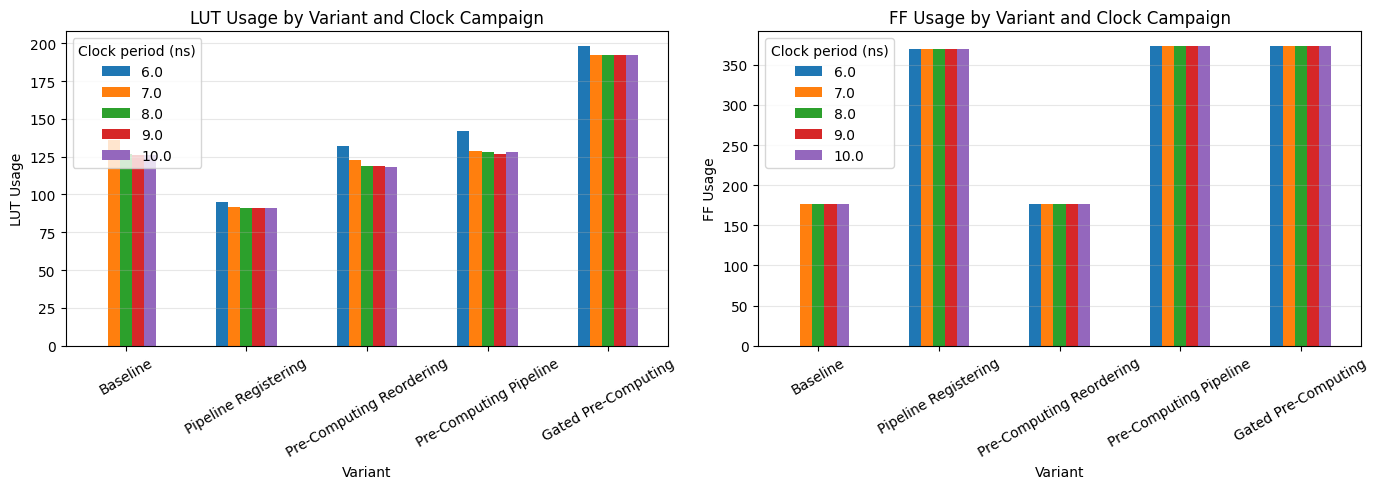

In [14]:
# --- STEP 06.3: RESOURCE USAGE COMPARISON (LUT / FF) ---

if not df_comparison.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax, col, title in [(ax1, "lut", "LUT Usage"), (ax2, "ff", "FF Usage")]:
        pivot = df_comparison.pivot(index="variant", columns="clk_period_ns", values=col)
        pivot = pivot.reindex(list(RENAME_VARIANTS.values()))
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(f"{title} by Variant and Clock Campaign")
        ax.set_ylabel(title)
        ax.set_xlabel("Variant")
        ax.legend(title="Clock period (ns)")
        ax.grid(True, alpha=0.3, axis="y")
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_FOLDER / "step08_resource_usage.png", dpi=300)
    plt.show()
else:
    print("No reports parsed yet; skipping plot.")

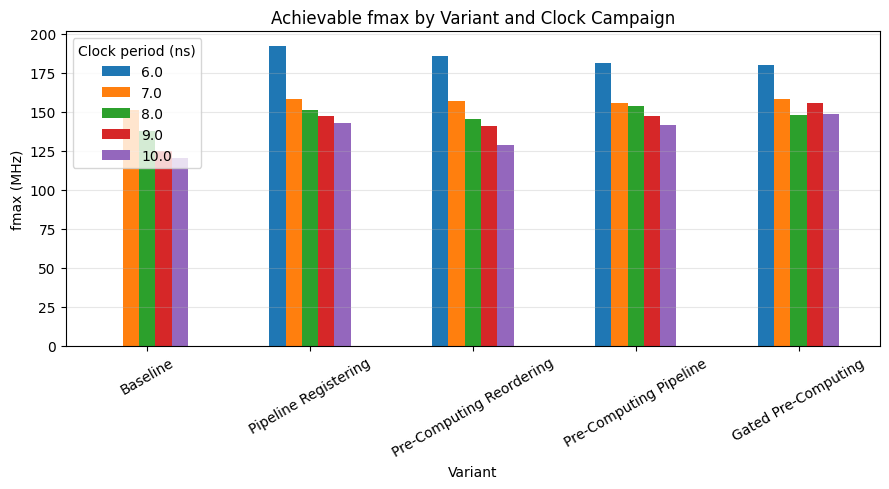

In [15]:
# --- STEP 06.4: TIMING COMPARISON (fmax) ---

if not df_comparison.empty:
    fig, ax = plt.subplots(figsize=(9, 5))

    pivot = df_comparison.pivot(index="variant", columns="clk_period_ns", values="fmax_mhz")
    pivot = pivot.reindex(list(RENAME_VARIANTS.values()))
    pivot.plot(kind="bar", ax=ax)

    ax.set_title("Achievable fmax by Variant and Clock Campaign")
    ax.set_ylabel("fmax (MHz)")
    ax.set_xlabel("Variant")
    ax.legend(title="Clock period (ns)")
    ax.grid(True, alpha=0.3, axis="y")
    ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_FOLDER / "step08_timing_fmax.png", dpi=300)
    plt.show()
else:
    print("No reports parsed yet; skipping plot.")

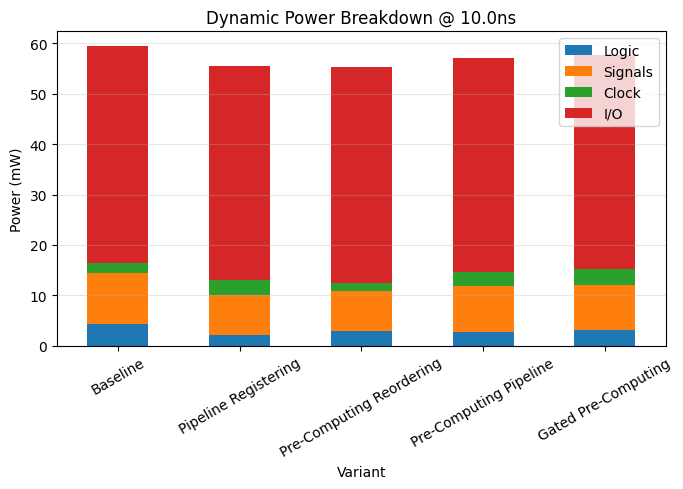

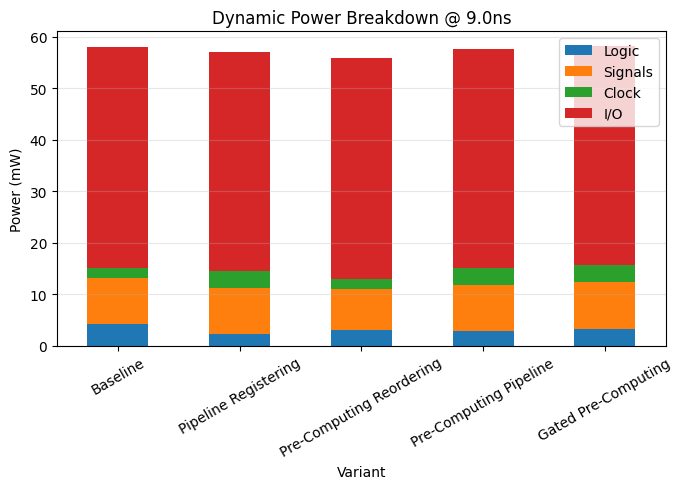

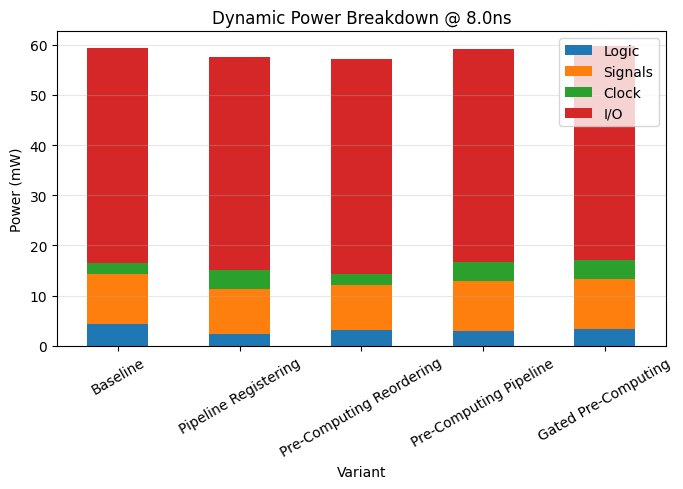

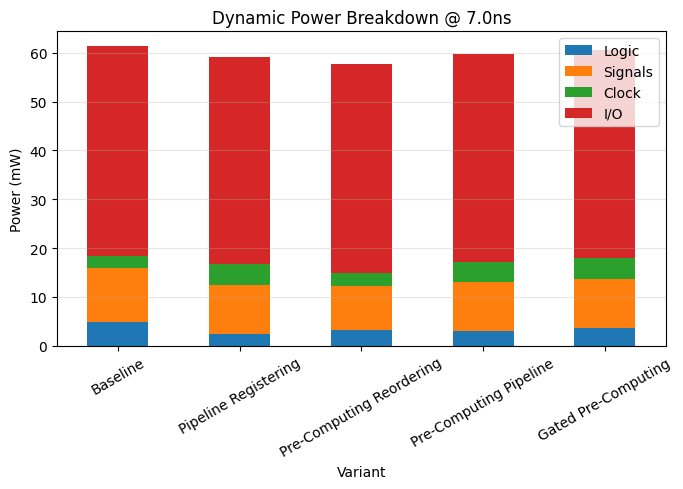

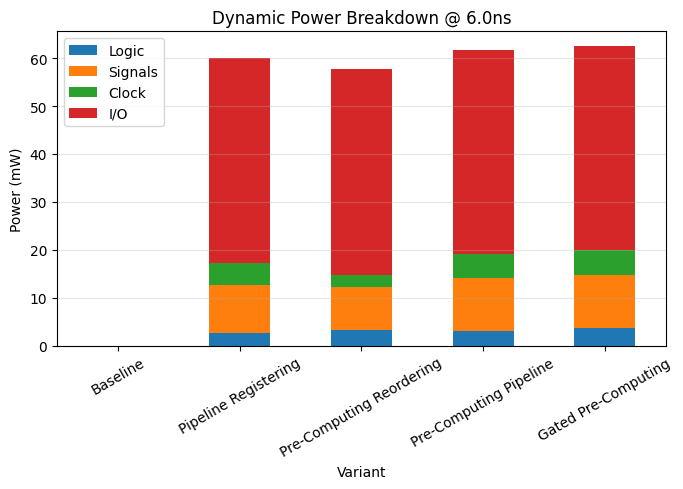

In [16]:
# --- STEP 06.5: POWER DISTRIBUTION ---

if not df_comparison.empty:
    for clk_period_ns in CLOCK_CAMPAIGNS:
        # Crea una nuova figura per ogni iterazione
        fig, ax = plt.subplots(figsize=(7, 5))

        subset = df_comparison[df_comparison["clk_period_ns"] == clk_period_ns].set_index("variant")
        subset = subset.reindex(list(RENAME_VARIANTS.values()))

        # Plot del breakdown di potenza
        subset[["logic_power_mw", "signals_power_mw", "clock_power_mw", "io_power_mw"]].plot(
            kind="bar", stacked=True, ax=ax
        )

        ax.set_title(f"Dynamic Power Breakdown @ {clk_period_ns}ns")
        ax.set_ylabel("Power (mW)")
        ax.set_xlabel("Variant")
        ax.legend(["Logic", "Signals", "Clock", "I/O"])
        ax.grid(True, alpha=0.3, axis="y")
        ax.tick_params(axis="x", rotation=30)

        plt.tight_layout()

        # Salva ogni figura con un nome file unico basato sul clock
        filename = OUTPUT_FIG_FOLDER / f"step08_power_breakdown_{clk_period_ns}ns.png"
        plt.savefig(filename, dpi=300)
        plt.show()
else:
    print("No reports parsed yet; skipping plot.")

In [17]:
# --- STEP 06.6: RELATIVE IMPROVEMENT VS BASELINE (STANDARD CAMPAIGN) ---

baseline_row = df_comparison[
    (df_comparison["variant"] == "Baseline") & (df_comparison["clk_period_ns"] == CLOCK_CAMPAIGNS[0])
] if not df_comparison.empty else pd.DataFrame()

if baseline_row.empty:
    print("Baseline metrics not available yet; run STEP 02 (and the Tcl flow) first.")
    df_summary = pd.DataFrame()
else:
    # Using dynamic_power_mw as the primary metric for optimization evaluation
    baseline_power = baseline_row["dynamic_power_mw"].iloc[0]
    baseline_fmax  = baseline_row["fmax_mhz"].iloc[0]

    summary_rows = []
    for _, row in df_comparison[df_comparison["clk_period_ns"] == CLOCK_CAMPAIGNS[0]].iterrows():
        power_reduction_pct = (
            (1 - row["dynamic_power_mw"] / baseline_power) * 100
            if baseline_power else None
        )
        fmax_gain_pct = (
            (row["fmax_mhz"] / baseline_fmax - 1) * 100
            if baseline_fmax and row["fmax_mhz"] is not None else None
        )
        summary_rows.append({
            "variant": row["variant"],
            "dynamic_power_mw": row["dynamic_power_mw"],
            "power_reduction_vs_baseline_pct": power_reduction_pct,
            "fmax_mhz": row["fmax_mhz"],
            "fmax_gain_vs_baseline_pct": fmax_gain_pct,
        })

    df_summary = pd.DataFrame(summary_rows)

_transform_dataframe(
    df_summary,
    rename_dict= {
        "variant": "Variant",
        "dynamic_power_mw": "Power (Dynamic) [mW]",
        "power_reduction_vs_baseline_pct": "Power Reduction vs. Baseline [%]",
        "fmax_mhz": "fmax [MHz]",
        "fmax_gain_vs_baseline_pct": "fmax Gain vs. Baseline [%]",
    }
)

,Variant,Power (Dynamic) [mW],Power Reduction vs. Baseline [%],fmax [MHz],fmax Gain vs. Baseline [%]
0,Baseline,16.494,0.000,120.106,0.000
1,Pipeline Registering,13.046,20.905,142.674,18.790
2,Pre-Computing Reordering,12.453,24.500,128.849,7.280
3,Pre-Computing Pipeline,14.544,11.822,141.403,17.732
4,Gated Pre-Computing,15.169,8.033,148.368,23.531


Baseline non trovata per 6.0ns; calcolo relativo ignorato per questo clock.


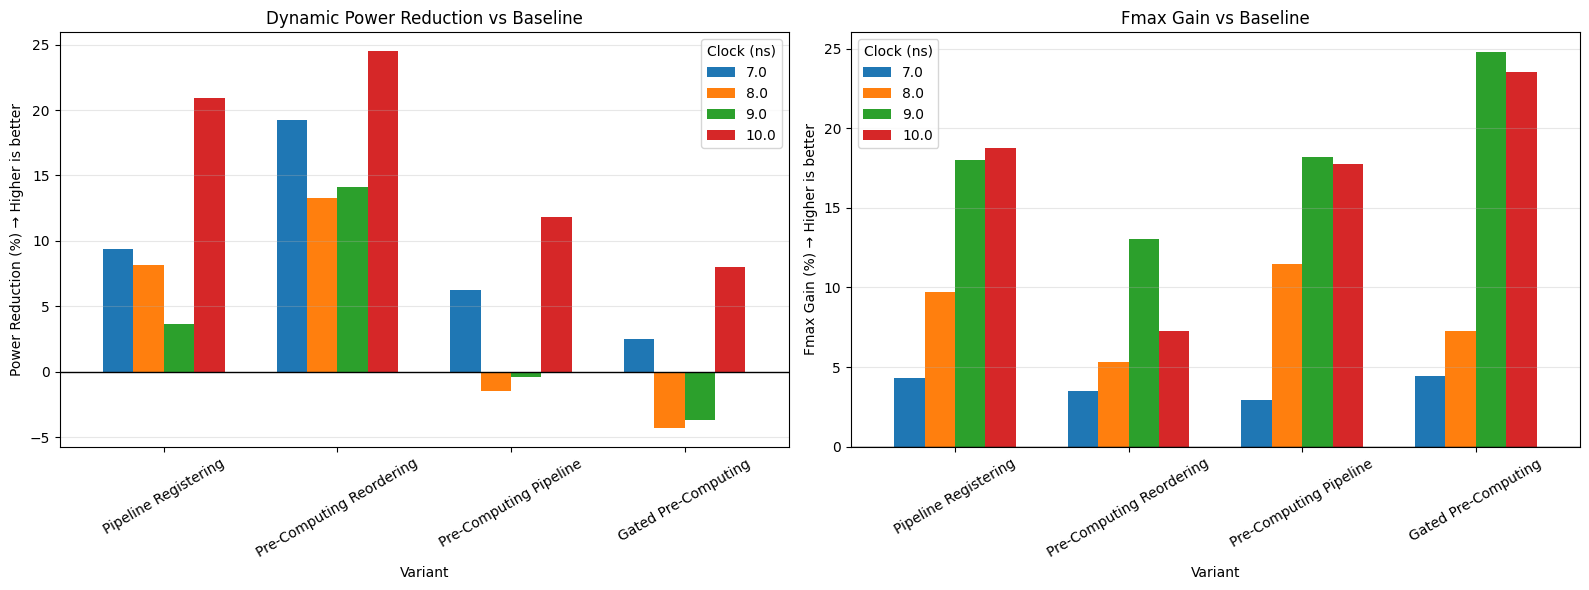

In [18]:
# --- STEP 06.7: RELATIVE IMPROVEMENT VS BASELINE (% BAR CHART) ---

if not df_comparison.empty:
    processed_rows = []

    # Raccogliamo e calcoliamo i dati per tutti i clock
    for clk_period_ns in CLOCK_CAMPAIGNS:
        df_clk = df_comparison[df_comparison["clk_period_ns"] == clk_period_ns].copy()

        baseline_mask = df_clk["variant"].str.contains("baseline", case=False, na=False)
        baseline_row = df_clk[baseline_mask]

        if not baseline_row.empty:
            actual_baseline_name = baseline_row["variant"].iloc[0]
            base_power = baseline_row["dynamic_power_mw"].iloc[0]
            base_fmax = baseline_row["fmax_mhz"].iloc[0]

            df_clk["power_reduction_pct"] = (1 - df_clk["dynamic_power_mw"] / base_power) * 100
            df_clk["fmax_gain_pct"] = (df_clk["fmax_mhz"] / base_fmax - 1) * 100

            # Escludiamo la baseline dai risultati da plottare
            df_plot_clk = df_clk[df_clk["variant"] != actual_baseline_name]
            processed_rows.append(df_plot_clk)
        else:
            print(f"Baseline non trovata per {clk_period_ns}ns; calcolo relativo ignorato per questo clock.")

    if processed_rows:
        # Uniamo tutti i dataframe processati
        df_all_plots = pd.concat(processed_rows)

        # Creiamo le tabelle pivot per avere Varianti sulle X e Clock raggruppati
        pivot_power = df_all_plots.pivot(index="variant", columns="clk_period_ns", values="power_reduction_pct")
        pivot_fmax = df_all_plots.pivot(index="variant", columns="clk_period_ns", values="fmax_gain_pct")

        # Riordiniamo le varianti se RENAME_VARIANTS esiste
        if 'RENAME_VARIANTS' in globals():
            plot_order = [v for v in RENAME_VARIANTS.values() if v in pivot_power.index]
            pivot_power = pivot_power.reindex(plot_order)
            pivot_fmax = pivot_fmax.reindex(plot_order)

        # Creiamo un'unica figura con due subplot affiancati
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Grafico 1: Riduzione Potenza
        pivot_power.plot(kind="bar", ax=ax1, width=0.7)
        ax1.set_title("Dynamic Power Reduction vs Baseline")
        ax1.set_ylabel("Power Reduction (%) → Higher is better")
        ax1.set_xlabel("Variant")
        ax1.axhline(0, color='black', linewidth=1)
        ax1.grid(True, alpha=0.3, axis="y")
        ax1.tick_params(axis="x", rotation=30)
        ax1.legend(title="Clock (ns)")

        # Grafico 2: Guadagno Velocità
        pivot_fmax.plot(kind="bar", ax=ax2, width=0.7)
        ax2.set_title("Fmax Gain vs Baseline")
        ax2.set_ylabel("Fmax Gain (%) → Higher is better")
        ax2.set_xlabel("Variant")
        ax2.axhline(0, color='black', linewidth=1)
        ax2.grid(True, alpha=0.3, axis="y")
        ax2.tick_params(axis="x", rotation=30)
        ax2.legend(title="Clock (ns)")

        plt.tight_layout()
        plt.savefig(OUTPUT_FIG_FOLDER / "step08_relative_improvement_grouped.png", dpi=300)
        plt.show()
    else:
        print("Dati insufficienti per generare il grafico dei miglioramenti relativi.")
else:
    print("No reports parsed yet; skipping plot.")

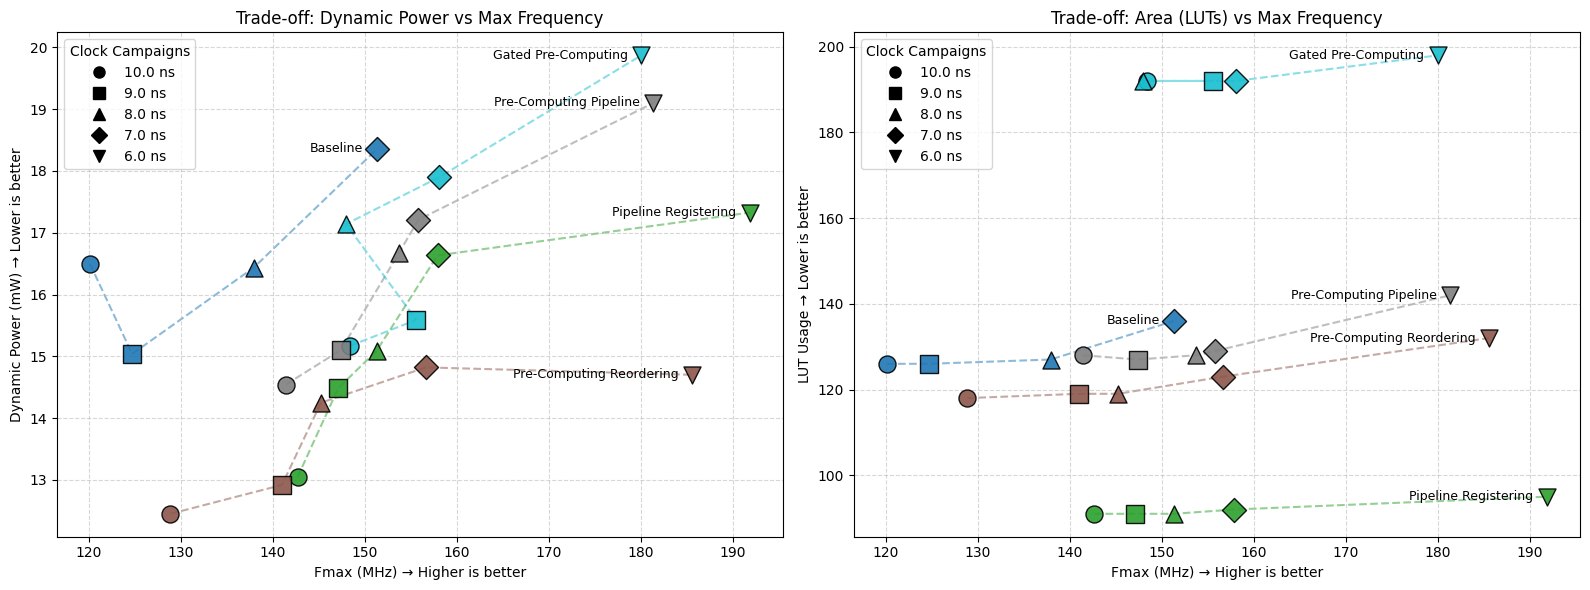

In [19]:
# --- STEP 06.8: ARCHITECTURAL TRADE-OFFS (SCATTER PLOTS) ---

if not df_comparison.empty:
    df_clean = df_comparison.dropna(subset=["fmax_mhz", "dynamic_power_mw", "lut"]).copy()

    if not df_clean.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        variants = df_clean["variant"].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(variants))) # pyright: ignore[reportAttributeAccessIssue]
        color_map = dict(zip(variants, colors))
        markers = ['o', 's', '^', 'D', 'v']

        for i, clk in enumerate(CLOCK_CAMPAIGNS):
            df_clk = df_clean[df_clean["clk_period_ns"] == clk]
            marker = markers[i % len(markers)]

            for _, row in df_clk.iterrows():
                var = row["variant"]
                fmax = row["fmax_mhz"]
                power = row["dynamic_power_mw"]
                lut = row["lut"]
                c = color_map[var]

                ax1.scatter(fmax, power, s=150, color=c, marker=marker, edgecolors="black", alpha=0.9, zorder=3)
                ax2.scatter(fmax, lut, s=150, color=c, marker=marker, edgecolors="black", alpha=0.9, zorder=3)

        for var in variants:
            df_var = df_clean[df_clean["variant"] == var].sort_values("clk_period_ns", ascending=False)
            if len(df_var) > 1:
                ax1.plot(df_var["fmax_mhz"], df_var["dynamic_power_mw"], color=color_map[var], linestyle="--", alpha=0.5, zorder=1)
                ax2.plot(df_var["fmax_mhz"], df_var["lut"], color=color_map[var], linestyle="--", alpha=0.5, zorder=1)

            last_pt = df_var.iloc[-1]

            # [MODIFICA]: ha='right' allinea il testo a destra rispetto alla coordinata.
            # xytext=(-10, 0) lo sposta fisicamente di 10 pixel a sinistra del punto.
            ax1.annotate(var, (last_pt["fmax_mhz"], last_pt["dynamic_power_mw"]),
                         xytext=(-10, 0), textcoords='offset points', ha='right', va='center', fontsize=9)
            ax2.annotate(var, (last_pt["fmax_mhz"], last_pt["lut"]),
                         xytext=(-10, 0), textcoords='offset points', ha='right', va='center', fontsize=9)

        import matplotlib.lines as mlines
        clock_legend = [mlines.Line2D([], [], color='black', marker=markers[i], linestyle='None',
                                      markersize=8, label=f'{clk} ns') for i, clk in enumerate(CLOCK_CAMPAIGNS)]

        ax1.set_title("Trade-off: Dynamic Power vs Max Frequency")
        ax1.set_xlabel("Fmax (MHz) → Higher is better")
        ax1.set_ylabel("Dynamic Power (mW) → Lower is better")
        ax1.grid(True, linestyle="--", alpha=0.5, zorder=0)
        ax1.legend(handles=clock_legend, title="Clock Campaigns", loc="upper left")

        ax2.set_title("Trade-off: Area (LUTs) vs Max Frequency")
        ax2.set_xlabel("Fmax (MHz) → Higher is better")
        ax2.set_ylabel("LUT Usage → Lower is better")
        ax2.grid(True, linestyle="--", alpha=0.5, zorder=0)
        ax2.legend(handles=clock_legend, title="Clock Campaigns", loc="upper left")

        plt.tight_layout()
        plt.savefig(OUTPUT_FIG_FOLDER / "step08_tradeoffs_combined.png", dpi=300)
        plt.show()
    else:
        print("Not enough complete data for trade-off plots.")
else:
    print("No reports parsed yet; skipping plot.")